# LDA + Parallel Scatter Matrices
**HPC Mini Project — Topic 42**  
Fisher's Linear Discriminant Analysis on the HAR Smartphones dataset.  
Serial and OpenMP-parallel scatter matrix computation via ctypes.

---
## Dataset
- **HAR (Human Activity Recognition)** — UCI / Kaggle
- 10 299 samples × 561 features
- 6 classes: WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING
- LDA extracts at most **C − 1 = 5** discriminant components


## 0 · Setup & Imports

In [19]:
import ctypes, os, subprocess, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.linalg import eigh
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
print('imports OK')

imports OK


## 1 · Compile C Libraries

In [20]:
print(os.getcwd())

/home/alaaeddine/Downloads/hpc


In [21]:
# Paths — adjust if your folder layout differs
SERIAL_DIR   = 'serial'
PARALLEL_DIR = 'parallel'

def compile_lib(directory, target):
    result = subprocess.run(['make', '-C', directory, '-B'],
                            capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f'Compilation failed in {directory}')
    path = os.path.join(directory, target)
    assert os.path.exists(path), f'{path} not found after make'
    print(f'  ✓  {path}')
    return os.path.abspath(path)

print('Compiling...')
serial_so   = compile_lib(SERIAL_DIR,   'lda_serial.so')
parallel_so = compile_lib(PARALLEL_DIR, 'lda_openmp.so')

Compiling...
  ✓  serial/lda_serial.so
  ✓  parallel/lda_openmp.so


## 2 · ctypes Wrappers

In [22]:
# ── type aliases ──────────────────────────────────────────────────────────────
c_double_p = ctypes.POINTER(ctypes.c_double)
c_int_p    = ctypes.POINTER(ctypes.c_int)

def _bind(lib, name, argtypes, restype=None):
    fn = getattr(lib, name)
    fn.argtypes = argtypes
    fn.restype  = restype if restype else ctypes.c_double
    return fn

# ── serial ────────────────────────────────────────────────────────────────────
_serial = ctypes.CDLL(serial_so)

_serial_means = _bind(_serial, 'compute_class_means',
    [c_double_p, c_int_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p, c_int_p, c_double_p],
    restype=None)

_serial_sw = _bind(_serial, 'compute_sw',
    [c_double_p, c_int_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p])

_serial_sb = _bind(_serial, 'compute_sb',
    [c_double_p, c_double_p, c_int_p,
     ctypes.c_int, ctypes.c_int,
     c_double_p],
    restype=None)

_serial_proj = _bind(_serial, 'lda_project',
    [c_double_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p],
    restype=None)

# ── parallel ──────────────────────────────────────────────────────────────────
_par = ctypes.CDLL(parallel_so)

_par_means = _bind(_par, 'compute_class_means',
    [c_double_p, c_int_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p, c_int_p, c_double_p],
    restype=None)

_par_sw = _bind(_par, 'compute_sw_parallel',
    [c_double_p, c_int_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p, ctypes.c_int])

_par_sb = _bind(_par, 'compute_sb',
    [c_double_p, c_double_p, c_int_p,
     ctypes.c_int, ctypes.c_int,
     c_double_p],
    restype=None)

_par_proj = _bind(_par, 'lda_project',
    [c_double_p, c_double_p,
     ctypes.c_int, ctypes.c_int, ctypes.c_int,
     c_double_p],
    restype=None)

print('ctypes bindings OK')

ctypes bindings OK


## 3 · Load & Inspect Dataset

In [23]:
# ── load ──────────────────────────────────────────────────────────────────────
# Download from Kaggle and place CSVs at data/train.csv, data/test.csv
# Or adjust paths below.
DATA_DIR = 'data'

train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test.csv')

print(f'Train shape : {train_df.shape}')
print(f'Test shape  : {test_df.shape}')
train_df['Activity'].value_counts()

Train shape : (7352, 563)
Test shape  : (2947, 563)


Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

In [24]:
# ── prepare numpy arrays ──────────────────────────────────────────────────────
le = LabelEncoder()

X_train = train_df.drop(columns=['subject', 'Activity']).values.astype(np.float64)
y_train = le.fit_transform(train_df['Activity'].values).astype(np.int32)

X_test  = test_df.drop(columns=['subject', 'Activity']).values.astype(np.float64)
y_test  = le.transform(test_df['Activity'].values).astype(np.int32)

n, d = X_train.shape
C    = len(le.classes_)
K    = C - 1   # max LDA components

print(f'n={n}, d={d}, C={C}, K={K}')
print('Classes:', le.classes_)

n=7352, d=561, C=6, K=5
Classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


In [25]:
from sklearn.preprocessing import StandardScaler

# === ADD THIS BLOCK ===
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float64)
X_test  = scaler.transform(X_test).astype(np.float64)
print("Features scaled with StandardScaler — ready for LDA")
# =======================

Features scaled with StandardScaler — ready for LDA


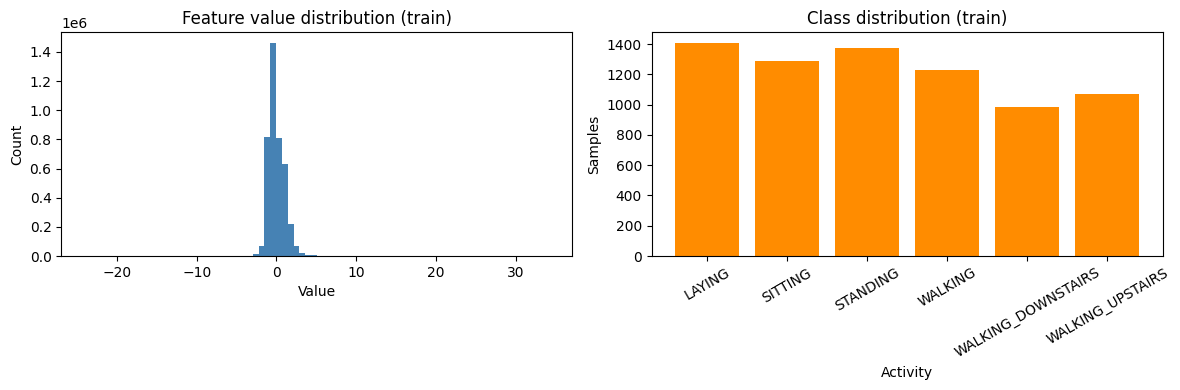

In [26]:
# ── feature distribution quick look ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train.flatten(), bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Feature value distribution (train)')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Count')

class_counts = np.bincount(y_train)
axes[1].bar(le.classes_, class_counts, color='darkorange')
axes[1].set_title('Class distribution (train)')
axes[1].set_xlabel('Activity'); axes[1].set_ylabel('Samples')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('figures/dataset_overview.png', dpi=150)
plt.show()

## 4 · Helper: C-compatible pointers

In [27]:
def dptr(arr):
    """Return a ctypes double pointer to a contiguous float64 numpy array."""
    assert arr.dtype == np.float64
    return arr.ctypes.data_as(c_double_p)

def iptr(arr):
    """Return a ctypes int pointer to a contiguous int32 numpy array."""
    assert arr.dtype == np.int32
    return arr.ctypes.data_as(c_int_p)

## 5 · Serial LDA

In [28]:
def run_serial_lda(X, y, n, d, C):
    """
    Full serial LDA pipeline.
    Returns (W, SW, SB, t_sw) where t_sw is S_W wall-clock time (seconds).
    """
    # allocate outputs
    means       = np.zeros((C, d),  dtype=np.float64)
    counts      = np.zeros(C,       dtype=np.int32)
    global_mean = np.zeros(d,       dtype=np.float64)
    SW          = np.zeros((d, d),  dtype=np.float64)
    SB          = np.zeros((d, d),  dtype=np.float64)

    # class means
    _serial_means(dptr(X), iptr(y),
                  n, d, C,
                  dptr(means), iptr(counts), dptr(global_mean))

    # S_W — timed inside C
    t_sw = _serial_sw(dptr(X), iptr(y), dptr(means),
                      n, d, C,
                      dptr(SW))

    # S_B
    _serial_sb(dptr(means), dptr(global_mean), iptr(counts),
               d, C, dptr(SB))

    # generalised eigenproblem: SB w = λ SW w
    # eigh returns eigenvalues in ascending order → take last K
    eigenvalues, eigenvectors = eigh(SB, SW + 1e-1 * np.eye(d))
    W = eigenvectors[:, -K:][:, ::-1].copy(order='C')  # [d × K], descending λ

    return W, SW, SB, t_sw, means, global_mean, counts

print('Running serial LDA...')
t0 = time.perf_counter()
W_serial, SW_s, SB_s, t_sw_serial, means_s, gm_s, counts_s = \
    run_serial_lda(X_train, y_train, n, d, C)
t_total_serial = time.perf_counter() - t0

print(f'  S_W computation time : {t_sw_serial:.4f} s')
print(f'  Total pipeline time  : {t_total_serial:.4f} s')
print(f'  W shape              : {W_serial.shape}')

Running serial LDA...
  S_W computation time : 1.5060 s
  Total pipeline time  : 1.5766 s
  W shape              : (561, 5)


## 6 · Parallel LDA (OpenMP)

In [29]:
def run_parallel_lda(X, y, n, d, C, num_threads):
    """
    Full parallel LDA pipeline.
    Returns (W, SW, SB, t_sw).
    """
    means       = np.zeros((C, d),  dtype=np.float64)
    counts      = np.zeros(C,       dtype=np.int32)
    global_mean = np.zeros(d,       dtype=np.float64)
    SW          = np.zeros((d, d),  dtype=np.float64)
    SB          = np.zeros((d, d),  dtype=np.float64)

    _par_means(dptr(X), iptr(y),
               n, d, C,
               dptr(means), iptr(counts), dptr(global_mean))

    t_sw = _par_sw(dptr(X), iptr(y), dptr(means),
                   n, d, C,
                   dptr(SW), num_threads)

    _par_sb(dptr(means), dptr(global_mean), iptr(counts),
            d, C, dptr(SB))

    eigenvalues, eigenvectors = eigh(SB, SW + 1e-1 * np.eye(d))
    W = eigenvectors[:, -K:][:, ::-1].copy(order='C')

    return W, SW, SB, t_sw

# quick sanity check with 4 threads
print('Running parallel LDA (4 threads)...')
W_par4, SW_p4, _, t_sw_par4 = run_parallel_lda(X_train, y_train, n, d, C, 4)

print(f'  S_W computation time : {t_sw_par4:.4f} s')
print(f'  Speedup vs serial    : {t_sw_serial / t_sw_par4:.2f}x')

Running parallel LDA (4 threads)...
  S_W computation time : 1.9392 s
  Speedup vs serial    : 0.78x


## 7 · Correctness Check
Serial and parallel S_W must agree to machine precision.

In [30]:
max_diff = np.max(np.abs(SW_s - SW_p4))
rel_diff = max_diff / (np.max(np.abs(SW_s)) + 1e-15)

print(f'Max absolute difference S_W serial vs parallel : {max_diff:.2e}')
print(f'Relative difference                            : {rel_diff:.2e}')
assert rel_diff < 1e-10, 'FAIL — results diverge'
print('✓  Results match')

Max absolute difference S_W serial vs parallel : 6.00e-11
Relative difference                            : 6.21e-15
✓  Results match


## 8 · Speedup Benchmark

In [32]:
THREAD_COUNTS = [1, 2, 4, 6, 8]
N_REPEATS     = 5   # average over multiple runs for stable timing

results = []  # list of dicts

# serial baseline (repeated for fair comparison)
serial_times = []
for _ in range(N_REPEATS):
    SW_tmp = np.zeros((d, d), dtype=np.float64)
    means_tmp = np.zeros((C, d), dtype=np.float64)
    counts_tmp = np.zeros(C, dtype=np.int32)
    gm_tmp = np.zeros(d, dtype=np.float64)
    _serial_means(dptr(X_train), iptr(y_train), n, d, C,
                  dptr(means_tmp), iptr(counts_tmp), dptr(gm_tmp))
    t = _serial_sw(dptr(X_train), iptr(y_train), dptr(means_tmp),
                   n, d, C, dptr(SW_tmp))
    serial_times.append(t)

t_serial_ref = np.mean(serial_times)
print(f'Serial S_W mean time ({N_REPEATS} runs): {t_serial_ref:.4f} s')

results.append({'threads': 'serial', 'time_mean': t_serial_ref,
                'time_std': np.std(serial_times), 'speedup': 1.0})

# parallel sweep
for T in THREAD_COUNTS:
    times = []
    for _ in range(N_REPEATS):
        SW_tmp = np.zeros((d, d), dtype=np.float64)
        means_tmp = np.zeros((C, d), dtype=np.float64)
        counts_tmp = np.zeros(C, dtype=np.int32)
        gm_tmp = np.zeros(d, dtype=np.float64)
        _par_means(dptr(X_train), iptr(y_train), n, d, C,
                   dptr(means_tmp), iptr(counts_tmp), dptr(gm_tmp))
        t = _par_sw(dptr(X_train), iptr(y_train), dptr(means_tmp),
                    n, d, C, dptr(SW_tmp), T)
        times.append(t)

    mean_t = np.mean(times)
    speedup = t_serial_ref / mean_t
    results.append({'threads': T, 'time_mean': mean_t,
                    'time_std': np.std(times), 'speedup': speedup})
    print(f'  T={T:2d}  mean={mean_t:.4f}s  speedup={speedup:.2f}x')

results_df = pd.DataFrame(results)
print('\n', results_df.to_string(index=False))

Serial S_W mean time (5 runs): 1.3846 s
  T= 1  mean=0.6013s  speedup=2.30x
  T= 2  mean=0.4853s  speedup=2.85x
  T= 4  mean=1.7748s  speedup=0.78x
  T= 6  mean=2.2659s  speedup=0.61x
  T= 8  mean=2.6011s  speedup=0.53x

 threads  time_mean  time_std  speedup
 serial   1.384623  0.032076 1.000000
      1   0.601333  0.017376 2.302591
      2   0.485346  0.009965 2.852856
      4   1.774788  0.045406 0.780163
      6   2.265872  0.026975 0.611077
      8   2.601128  0.130858 0.532317


## 9 · Speedup & Efficiency Plots

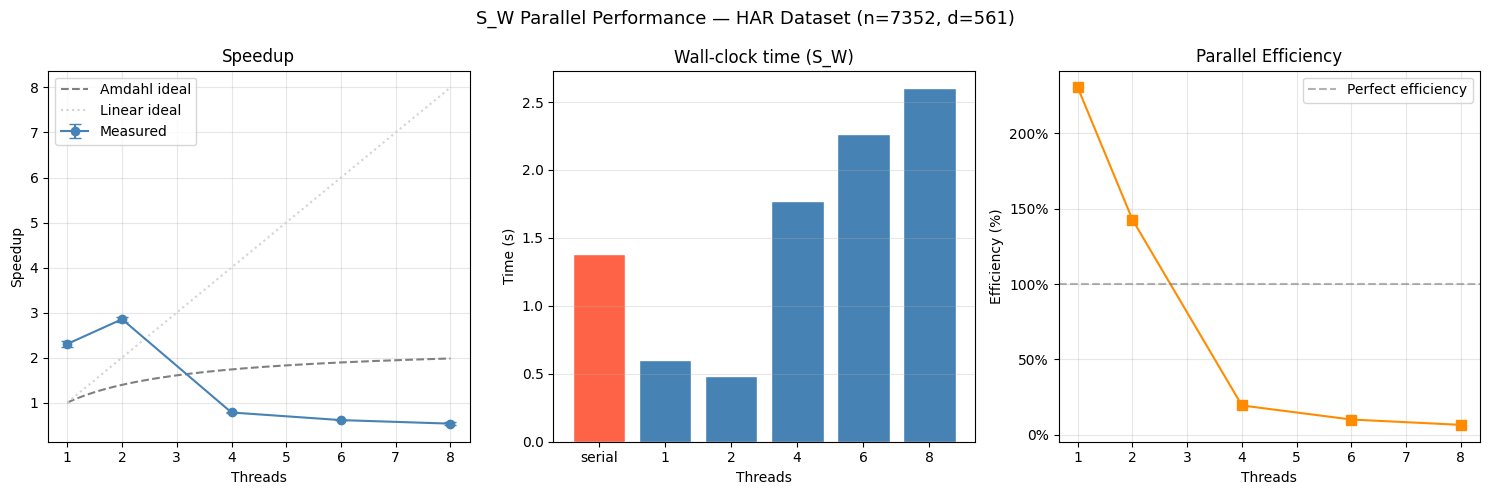


Estimated parallel fraction p ≈ 0.566
Theoretical max speedup (Amdahl) ≈ 2.3x


In [33]:
os.makedirs('figures', exist_ok=True)

par_df  = results_df[results_df['threads'] != 'serial'].copy()
par_df['threads'] = par_df['threads'].astype(int)
par_df['efficiency'] = par_df['speedup'] / par_df['threads']

# Amdahl ideal curve
# Estimate serial fraction p: from 1-thread parallel time vs serial time
t1 = par_df[par_df['threads'] == 1]['time_mean'].values[0]
p  = 1 - (t1 / t_serial_ref)   # parallel fraction (rough)
T_range = np.linspace(1, max(THREAD_COUNTS), 200)
amdahl  = 1.0 / ((1 - p) + p / T_range)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('S_W Parallel Performance — HAR Dataset (n=7352, d=561)', fontsize=13)

# — speedup —
ax = axes[0]
ax.plot(T_range, amdahl, '--', color='gray', label='Amdahl ideal')
ax.plot(T_range, T_range, ':', color='lightgray', label='Linear ideal')
ax.errorbar(par_df['threads'], par_df['speedup'],
            yerr=par_df['time_std'] / par_df['time_mean'] * par_df['speedup'],
            fmt='o-', color='steelblue', capsize=4, label='Measured')
ax.set_xlabel('Threads'); ax.set_ylabel('Speedup')
ax.set_title('Speedup')
ax.legend(); ax.grid(True, alpha=0.3)

# — wall-clock time —
ax = axes[1]
ax.bar(['serial'] + list(par_df['threads'].astype(str)),
       [t_serial_ref] + list(par_df['time_mean']),
       color=['tomato'] + ['steelblue'] * len(par_df),
       edgecolor='white')
ax.set_xlabel('Threads'); ax.set_ylabel('Time (s)')
ax.set_title('Wall-clock time (S_W)')
ax.grid(axis='y', alpha=0.3)

# — parallel efficiency —
ax = axes[2]
ax.plot(par_df['threads'], par_df['efficiency'] * 100,
        's-', color='darkorange', markersize=7)
ax.axhline(100, linestyle='--', color='gray', alpha=0.6, label='Perfect efficiency')
ax.set_xlabel('Threads'); ax.set_ylabel('Efficiency (%)')
ax.set_title('Parallel Efficiency')
ax.yaxis.set_major_formatter(ticker.PercentFormatter())
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/speedup.png', dpi=150)
plt.show()

print(f'\nEstimated parallel fraction p ≈ {p:.3f}')
print(f'Theoretical max speedup (Amdahl) ≈ {1/(1-p):.1f}x')

## 10 · LDA Projection & Visualisation

In [34]:
# Project training data onto top-5 LDA axes using the serial W
W = W_serial.astype(np.float64)
W_c = np.ascontiguousarray(W)

Y_train = np.zeros((n, K),          dtype=np.float64)
Y_test  = np.zeros((len(y_test), K), dtype=np.float64)

_serial_proj(dptr(X_train), dptr(W_c), n, d, K, dptr(Y_train))
_serial_proj(dptr(X_test),  dptr(W_c), len(y_test), d, K, dptr(Y_test))

print(f'Projected train: {Y_train.shape}')
print(f'Projected test : {Y_test.shape}')

Projected train: (7352, 5)
Projected test : (2947, 5)


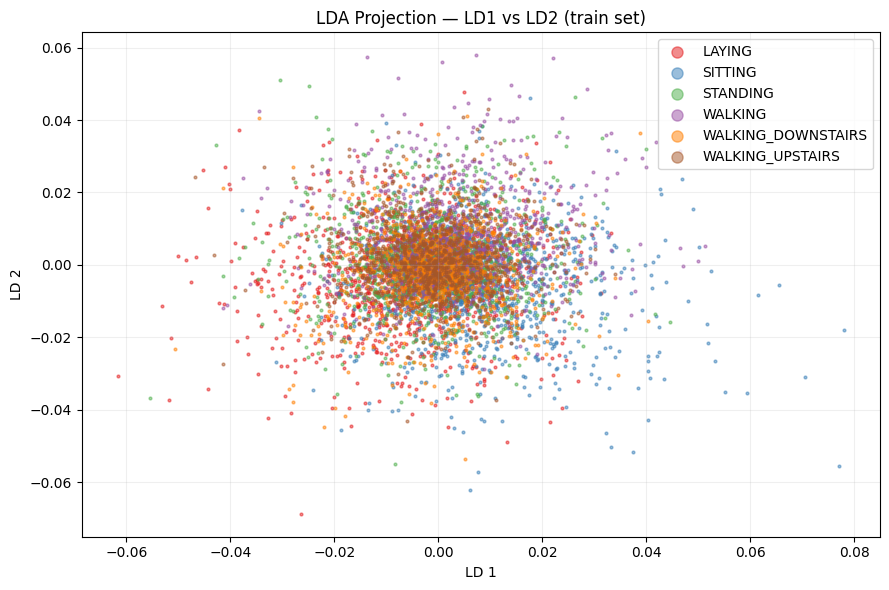

In [35]:
# 2D scatter: LD1 vs LD2
COLORS = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628']

fig, ax = plt.subplots(figsize=(9, 6))
for c_idx, label in enumerate(le.classes_):
    mask = y_train == c_idx
    ax.scatter(Y_train[mask, 0], Y_train[mask, 1],
               s=4, alpha=0.5, color=COLORS[c_idx], label=label)

ax.set_xlabel('LD 1'); ax.set_ylabel('LD 2')
ax.set_title('LDA Projection — LD1 vs LD2 (train set)')
ax.legend(markerscale=4, loc='best')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('figures/lda_projection.png', dpi=150)
plt.show()

## 11 · Classification Accuracy

In [36]:
# 1-NN classifier on LDA-projected space
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(Y_train, y_train)
y_pred = knn.predict(Y_test)

acc = accuracy_score(y_test, y_pred)
print(f'LDA (K={K}) + 1-NN accuracy on test set: {acc:.4f} ({acc*100:.2f}%)')
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

LDA (K=5) + 1-NN accuracy on test set: 0.1663 (16.63%)

                    precision    recall  f1-score   support

            LAYING       0.19      0.20      0.20       537
           SITTING       0.17      0.16      0.16       491
          STANDING       0.18      0.19      0.18       532
           WALKING       0.20      0.20      0.20       496
WALKING_DOWNSTAIRS       0.14      0.14      0.14       420
  WALKING_UPSTAIRS       0.11      0.10      0.11       471

          accuracy                           0.17      2947
         macro avg       0.16      0.16      0.16      2947
      weighted avg       0.17      0.17      0.17      2947



In [37]:
# Compare accuracy: serial W vs parallel W (should be identical)
W_par_c = np.ascontiguousarray(W_par4.astype(np.float64))
Y_test_par = np.zeros((len(y_test), K), dtype=np.float64)
_par_proj(dptr(X_test), dptr(W_par_c), len(y_test), d, K, dptr(Y_test_par))

knn2 = KNeighborsClassifier(n_neighbors=1)
knn2.fit(np.zeros_like(Y_train), y_train)   # placeholder — reuse projection
# Re-project train with parallel W
Y_train_par = np.zeros((n, K), dtype=np.float64)
_par_proj(dptr(X_train), dptr(W_par_c), n, d, K, dptr(Y_train_par))
knn2.fit(Y_train_par, y_train)
y_pred_par = knn2.predict(Y_test_par)
acc_par = accuracy_score(y_test, y_pred_par)

print(f'Serial   accuracy : {acc:.4f}')
print(f'Parallel accuracy : {acc_par:.4f}')
print(f'Difference        : {abs(acc - acc_par):.6f}')

Serial   accuracy : 0.1663
Parallel accuracy : 0.1663
Difference        : 0.000000


## 12 · Summary Table (for report)

In [38]:
summary = results_df.copy()
summary['time_mean'] = summary['time_mean'].map('{:.4f}'.format)
summary['time_std']  = summary['time_std'].map('{:.4f}'.format)
summary['speedup']   = summary['speedup'].map('{:.2f}'.format)

print('=== S_W Timing Summary ===')
print(summary.to_string(index=False))
print(f'\nClassification accuracy (serial)  : {acc:.4f}')
print(f'Classification accuracy (parallel): {acc_par:.4f}')

=== S_W Timing Summary ===
threads time_mean time_std speedup
 serial    1.3846   0.0321    1.00
      1    0.6013   0.0174    2.30
      2    0.4853   0.0100    2.85
      4    1.7748   0.0454    0.78
      6    2.2659   0.0270    0.61
      8    2.6011   0.1309    0.53

Classification accuracy (serial)  : 0.1663
Classification accuracy (parallel): 0.1663


In [39]:
# Check CPU info
!lscpu | grep -E "^CPU\(s\)|Thread|Model name|MHz"

# Check if hyperthreading is confusing OpenMP
import os
print(f"Python reports CPU count: {os.cpu_count()}")
print(f"OpenMP threads available: {os.environ.get('OMP_NUM_THREADS', 'not set')}")

CPU(s):                                  8
Model name:                              Intel(R) Core(TM) i5-8350U CPU @ 1.70GHz
Thread(s) per core:                      2
CPU(s) scaling MHz:                      67%
CPU max MHz:                             3600.0000
CPU min MHz:                             400.0000
Python reports CPU count: 8
OpenMP threads available: not set


In [40]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float64)
X_test_scaled  = scaler.transform(X_test).astype(np.float64)

# Use SVD solver — much more stable for this dataset (does NOT require S_W to be invertible)
lda_sk = LinearDiscriminantAnalysis(
    n_components=K, 
    solver='svd'          # ← this is the key
    # shrinkage=None     # not needed with svd
)

X_train_lda = lda_sk.fit_transform(X_train_scaled, y_train)
X_test_lda  = lda_sk.transform(X_test_scaled)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_lda, y_train)
acc_sk = accuracy_score(y_test, knn.predict(X_test_lda))

print(f"sklearn LDA (svd) + 1-NN accuracy: {acc_sk:.4f} ({acc_sk*100:.2f}%)")

sklearn LDA (svd) + 1-NN accuracy: 0.9634 (96.34%)
